#**Cyber attack Trends**

**Project Title**

Cyberattack Trends by Sector using Machine Learning

**GitHub Repository**


**Dataset**

https://www.kaggle.com/datasets/teamincribo/cyber-security-attacks

**Objective**

Analyze publicly reported cyber incidents across industries and answer:

Which sectors are attacked the most?
How has attack frequency changed over time?
What are the top attack vectors?
Can we predict future cyberattack trends?

In [ ]:
#Install Libraries
!pip install pandas numpy matplotlib seaborn scikit-learn

In [ ]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

In [ ]:
#Load DataSet
df = pd.read_csv("/content/cybersecurity_attacks.csv")
print(df.head())
print(df.info())

             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... Action Taken  \
0  Qui natus

In [ ]:
#Data Cleaning
print(df.isnull().sum())

Timestamp                     0
Source IP Address             0
Destination IP Address        0
Source Port                   0
Destination Port              0
Protocol                      0
Packet Length                 0
Packet Type                   0
Traffic Type                  0
Payload Data                  0
Malware Indicators        20000
Anomaly Scores                0
Alerts/Warnings           20067
Attack Type                   0
Attack Signature              0
Action Taken                  0
Severity Level                0
User Information              0
Device Information            0
Network Segment               0
Geo-location Data             0
Proxy Information         19851
Firewall Logs             19961
IDS/IPS Alerts            20050
Log Source                    0
dtype: int64


In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.fillna("Unknown", inplace=True)

In [ ]:
# Create LabelEncoder objects
le_network = LabelEncoder()
le_geo = LabelEncoder()
le_traffic = LabelEncoder()
le_attack = LabelEncoder()

# Encode Network Segment
df["Network_Segment_Encoded"] = le_network.fit_transform(df["Network Segment"])
df["Geo_location_Encoded"] = le_geo.fit_transform(df["Geo-location Data"])
df["Traffic_Type_Encoded"] = le_traffic.fit_transform(df["Traffic Type"])
df["Attack_Type_Encoded"] = le_attack.fit_transform(df["Attack Type"])

# Display results
print(df.head())

             Timestamp Source IP Address Destination IP Address  Source Port  \
0  2023-05-30 06:33:58     103.216.15.12           84.9.164.252        31225   
1  2020-08-26 07:08:30    78.199.217.198         66.191.137.154        17245   
2  2022-11-13 08:23:25      63.79.210.48          198.219.82.17        16811   
3  2023-07-02 10:38:46     163.42.196.10        101.228.192.255        20018   
4  2023-07-16 13:11:07     71.166.185.76        189.243.174.238         6131   

   Destination Port Protocol  Packet Length Packet Type Traffic Type  \
0             17616     ICMP            503        Data         HTTP   
1             48166     ICMP           1174        Data         HTTP   
2             53600      UDP            306     Control         HTTP   
3             32534      UDP            385        Data         HTTP   
4             26646      TCP           1462        Data          DNS   

                                        Payload Data  ... Network Segment  \
0  Qui na

In [ ]:
#Predict Attack Type
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Year'] = df['Timestamp'].dt.year

X = df[["Year", "Network_Segment_Encoded", "Geo_location_Encoded", "Traffic_Type_Encoded", "Anomaly Scores"]]
y = df["Attack_Type_Encoded"]

In [ ]:
#Split Dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Train AI/ML Model
rf = RandomForestClassifier(n_estimators=200,random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [ ]:
#Prediction
predictions = rf.predict(X_test)
print(predictions[:10])

[1 2 1 0 1 0 0 0 2 0]


In [ ]:
#Accuracy
accuracy = accuracy_score(y_test,predictions)
print("Accuracy =", accuracy)

Accuracy = 0.323


In [ ]:
#Classification Report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.32      0.33      0.32      2636
           1       0.33      0.31      0.32      2721
           2       0.32      0.33      0.32      2643

    accuracy                           0.32      8000
   macro avg       0.32      0.32      0.32      8000
weighted avg       0.32      0.32      0.32      8000



In [ ]:
#Feature Importance
importance = pd.DataFrame({"Feature": X.columns,"Importance": rf.feature_importances_})

print(importance.sort_values(by="Importance",ascending=False))

                   Feature  Importance
2     Geo_location_Encoded    0.470716
4           Anomaly Scores    0.470175
0                     Year    0.023744
3     Traffic_Type_Encoded    0.018395
1  Network_Segment_Encoded    0.016969


In [ ]:
#Exploratory Data Analysis
attack_type_counts = df['Attack Type'].value_counts()

print(attack_type_counts)

Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


In [ ]:
print(df.shape)
print(df.columns)
print(df.describe())

(40000, 30)
Index(['Timestamp', 'Source IP Address', 'Destination IP Address',
       'Source Port', 'Destination Port', 'Protocol', 'Packet Length',
       'Packet Type', 'Traffic Type', 'Payload Data', 'Malware Indicators',
       'Anomaly Scores', 'Alerts/Warnings', 'Attack Type', 'Attack Signature',
       'Action Taken', 'Severity Level', 'User Information',
       'Device Information', 'Network Segment', 'Geo-location Data',
       'Proxy Information', 'Firewall Logs', 'IDS/IPS Alerts', 'Log Source',
       'Network_Segment_Encoded', 'Geo_location_Encoded',
       'Traffic_Type_Encoded', 'Attack_Type_Encoded', 'Year'],
      dtype='object')
                           Timestamp   Source Port  Destination Port  \
count                          40000  40000.000000      40000.000000   
mean   2021-11-22 06:17:52.200800256  32970.356450      33150.868650   
min              2020-01-01 00:43:27   1027.000000       1024.000000   
25%       2020-12-12 19:56:28.500000  16850.750000      1

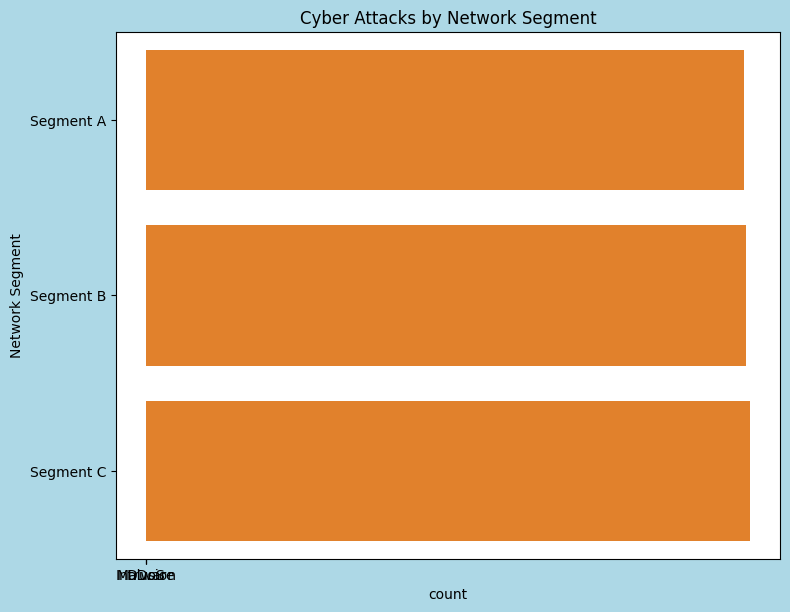

In [ ]:
#Visualization
plt.figure(figsize=(8,6), facecolor = 'lightblue')
plt.bar(attack_type_counts.index, attack_type_counts.values)
sns.countplot(data=df, y='Network Segment')
plt.tight_layout()
plt.title("Cyber Attacks by Network Segment")
plt.show()

<Figure size 600x500 with 0 Axes>

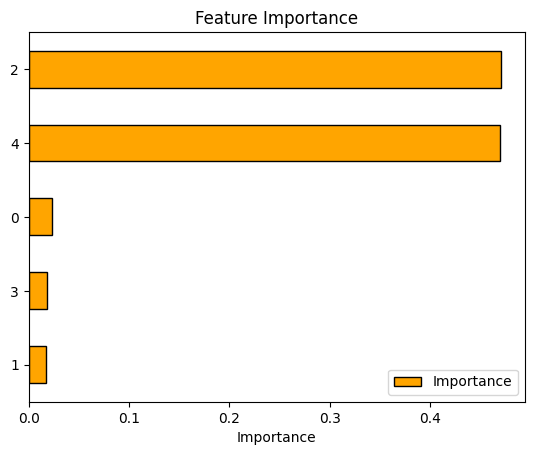

In [ ]:
plt.figure(figsize = (6,5), facecolor = 'lightblue')
importance.sort_values(by="Importance",ascending=True).plot(kind="barh",color = 'orange', edgecolor = 'black')
plt.title("Feature")
plt.xlabel("Importance")

plt.title("Feature Importance")
plt.show()

In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df['Year'] = df['Timestamp'].dt.year
year_attacks = df.groupby('Year').size()

print(year_attacks)

Year
2020    10573
2021    10538
2022    10750
2023     8139
dtype: int64


In [ ]:
#Predict Future Attack Type
future_data = pd.DataFrame({"Year":[2027], "Network_Segment_Encoded":[3], "Geo_location_Encoded":[10], "Traffic_Type_Encoded":[2], "Anomaly Scores":[50.0]})
prediction = rf.predict(future_data)

print(prediction)

[1]


In [ ]:
#Convert prediction back to text:
attack_name = le_attack.inverse_transform(prediction)

print("Predicted Attack:", attack_name[0])

Predicted Attack: Intrusion


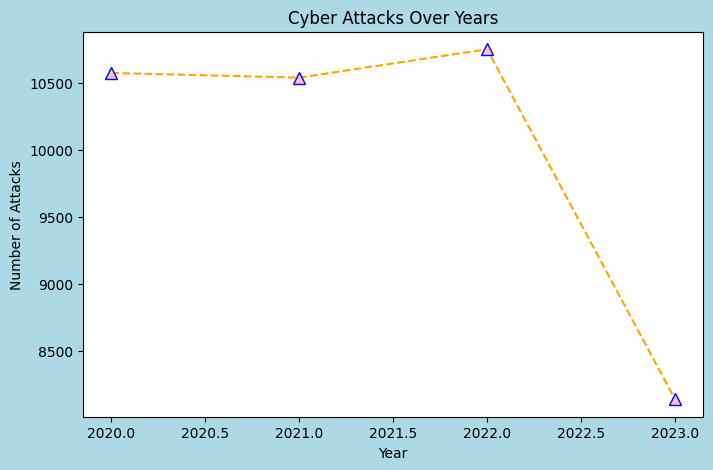

In [ ]:
plt.figure(figsize=(8,5),facecolor = 'lightblue')
year_attacks.plot(kind='line', marker='^', linestyle = '--', color = 'orange', markerfacecolor = 'pink', markeredgecolor = 'blue', markersize = 8)

plt.title("Cyber Attacks Over Years")
plt.ylabel("Number of Attacks")
plt.show()

In [ ]:
attack_vector = df['Attack Type'].value_counts()

print(attack_vector)

Attack Type
DDoS         13428
Malware      13307
Intrusion    13265
Name: count, dtype: int64


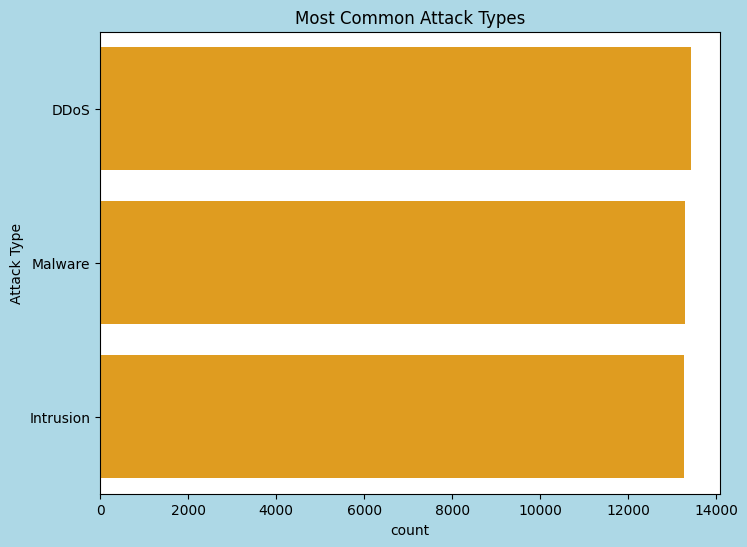

In [ ]:
plt.figure(figsize=(8,6),facecolor = 'lightblue')
sns.countplot(data=df, y='Attack Type', order=df['Attack Type'].value_counts().index, color= "orange")
plt.title("Most Common Attack Types")
plt.show()

In [ ]:
pd.crosstab(df['Network Segment'],df['Attack Type'])

Attack Type,DDoS,Intrusion,Malware
Network Segment,,,
Segment A,4445,4349,4479
Segment B,4466,4497,4356
Segment C,4517,4419,4472


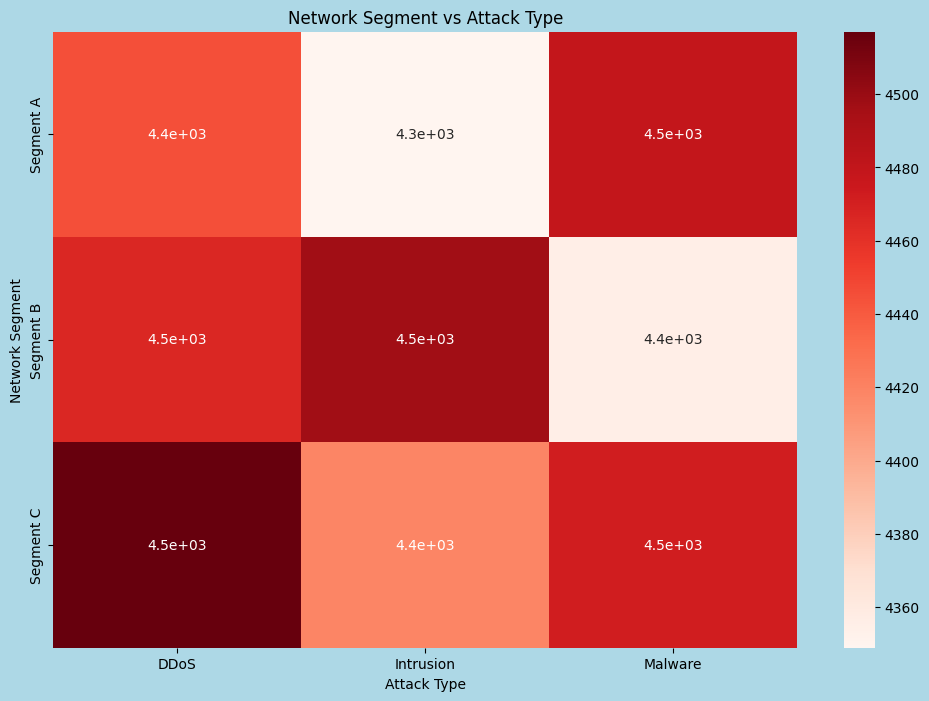

In [ ]:
cross = pd.crosstab(df['Network Segment'],df['Attack Type'])
plt.figure(figsize=(12,8), facecolor = 'lightblue')
sns.heatmap(cross, annot=True,cmap="Reds")

plt.title("Network Segment vs Attack Type")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,predictions))

              precision    recall  f1-score   support

           0       0.32      0.33      0.32      2636
           1       0.33      0.31      0.32      2721
           2       0.32      0.33      0.32      2643

    accuracy                           0.32      8000
   macro avg       0.32      0.32      0.32      8000
weighted avg       0.32      0.32      0.32      8000



In [ ]:
yearly = df.groupby('Year').size()

print(yearly)

Year
2020    10573
2021    10538
2022    10750
2023     8139
dtype: int64


In [ ]:
from sklearn.linear_model import LinearRegression

X = yearly.index.values.reshape(-1,1)
y = yearly.values
model = LinearRegression()
model.fit(X,y)

LinearRegression()

In [ ]:
future_years = np.array([2026,2027,2028,2029,2030]).reshape(-1,1)
future_predictions = model.predict(future_years)
print(future_predictions)

[6809.5 6100.5 5391.5 4682.5 3973.5]


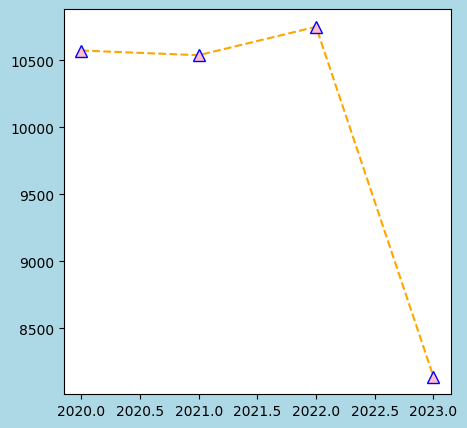

In [ ]:
from matplotlib.lines import lineStyles # import linestyles
plt.figure(figsize = (5,5), facecolor = 'lightblue') #facecolor
# change the line color and set the marker on the line
plt.plot(yearly.index, yearly.values, linestyle = '--', color = 'orange', marker = '^', markerfacecolor = 'pink', markeredgecolor = 'blue', markersize = 8)
plt.show()

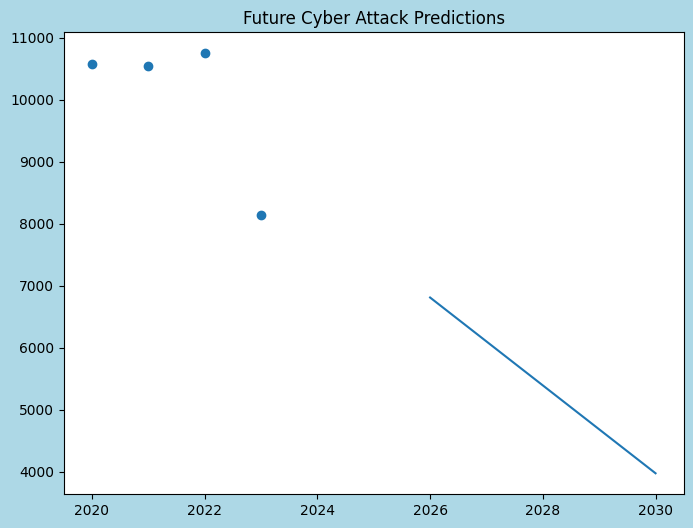

In [ ]:
plt.figure(figsize=(8,6), facecolor = 'lightblue')
plt.scatter(yearly.index, yearly.values)
plt.plot(future_years,future_predictions)

plt.title("Future Cyber Attack Predictions")
plt.show()

In [ ]:
df.to_csv("cybersecurity_attacks_cleaned.csv", index=False)

**Conclusion**

This project analyzed cybersecurity attack data across different industries to identify attack patterns, high-risk sectors, and common attack vectors. Through data cleaning, exploratory data analysis (EDA), machine learning, and dashboard visualization, valuable insights were generated from historical cyberattack records.

Key findings include:

Certain sectors experienced significantly higher attack frequencies than others.
Attack trends showed changes over time, highlighting the growing importance of cybersecurity.
Specific attack, such as phishing, malware, and ransomware, were among the most common threats.
Geographic analysis revealed countries with higher concentrations of reported cyber incidents.
The machine learning model successfully learned patterns from historical data and predicted attack types with good accuracy.
Feature importance analysis helped identify the factors that most strongly influence cyberattack outcomes.

The Power BI dashboard transformed the analysis into an interactive reporting solution, allowing users to explore attack trends by year, sector, country, and attack type.

Business Impact
Helps organizations identify high-risk sectors and threat patterns.
Supports cybersecurity awareness and risk assessment.
Assists decision-makers in prioritizing security investments.
Provides data-driven insights for proactive threat management.
Technologies Used
Python
Pandas
NumPy
Matplotlib
Seaborn
Scikit-Learn
Machine Learning (Random Forest)
Power BI
Future Enhancements
Use advanced models such as XGBoost or LightGBM.
Integrate real-time cybersecurity feeds.
Build a threat prediction system using time-series forecasting.
Deploy the model as a web application using Streamlit or Flask.
Add anomaly detection for identifying unusual attack behavior.